"""
# **K-Means and Kernelized Clustering - Coding Assignment** **[30 points]**

## **Objective:**
In this assignment, students will:
- Implement the K-Means clustering algorithm from scratch.
- Apply K-Means to cluster non-linearly separable data.
- Understand limitations of K-Means and motivate the need for kernelization.
- Implement a basic form of **Kernel K-Means** using RBF kernel.

---


Criteria	Points (Total: 60 Points)
1. Dataset Generation
- Generate dataset using make_moons(n_samples=300, noise=0.1, random_state=42)	5
- Scatter plot to visualize structure	5
2. K-Means Implementation
- Randomly select k unique data points as initial centroids	2
- Return cluster indices for each point	2
- Compute mean of points assigned to each cluster	2
- Return final labels and centroids	8
- Run K-Means and plot resulting clusters	6
- Subplot comparing ground truth vs. K-Means predictions	5
3. Kernel K-Means
- Implement RBF (Gaussian) kernel matrix using pairwise squared Euclidean distances	10
- Apply kernel K-Means using RBF kernel matrix	5
- Plot and compare clustering output with standard K-Means	5
4. Final Questions
- Answer markdown questions (1 point each)	5


## **1. Load Libraries and Dataset**
"""


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_kernels

"""
### **Task 1: Generate and visualize a non-linearly separable dataset**
Use sklearn's `make_moons` to generate 2D data.
"""

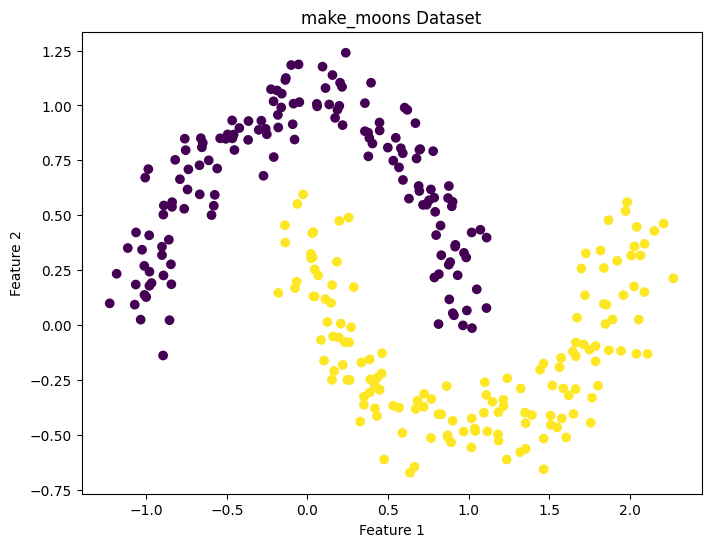

In [5]:
# TODO: Generate dataset using make_moons (n_samples=300, noise=0.1, random_state=42) (5 points)
# TODO: Plot the dataset using scatter plot to visualize its structure (5 points)

X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("make_moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

"""
## **2. Implement K-Means from Scratch**
### Task 2: Write your own implementation of the K-Means clustering algorithm.
"""

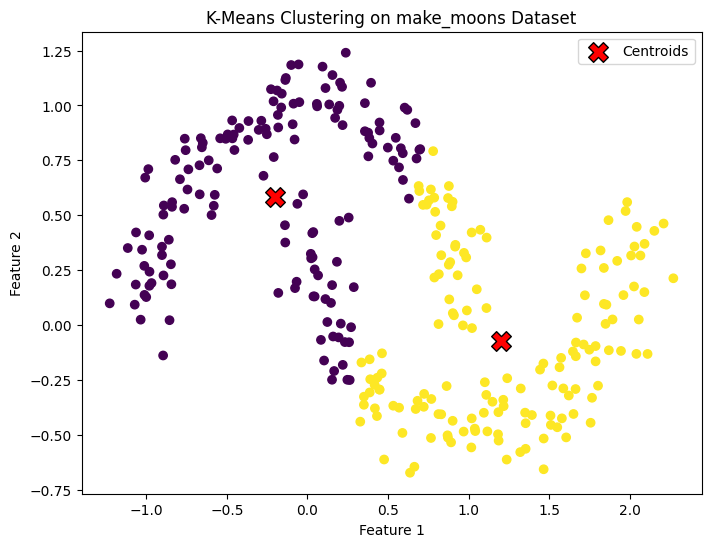

In [10]:
def initialize_centroids(X, k):
    """
    TODO: Randomly select k unique data points from X as initial centroids (2 points)
    """
    indices = np.random.choice(X.shape[0], size=k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    """
    TODO: Assign each point to the closest centroid
    Return a list of cluster indices for each point (2 points)
    """
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    """
    TODO: Compute the mean of all points assigned to each cluster (2 points)
    Return updated centroids
    """
    centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        centroids.append(cluster_points.mean(axis=0))
        
    return np.array(centroids)

def kmeans(X, k, max_iters=100):
    """
    TODO: Implement the full K-Means loop
    - Initialize centroids
    - Iterate (assign -> update) until convergence or max_iters
    Return final labels and centroids (8 points)
    """
    centroids = initialize_centroids(X, k)

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

# TODO: Run your K-Means implementation on the dataset and plot the resulting clusters (6 points)
np.random.seed(42)
labels, centroids = kmeans(X, k=2)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X', c='red', edgecolors='black', label='Centroids')
plt.title("K-Means Clustering on make_moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

"""
## **3. Limitations of K-Means**
### Task 3: Visualize how K-Means struggles with non-linear boundaries
"""

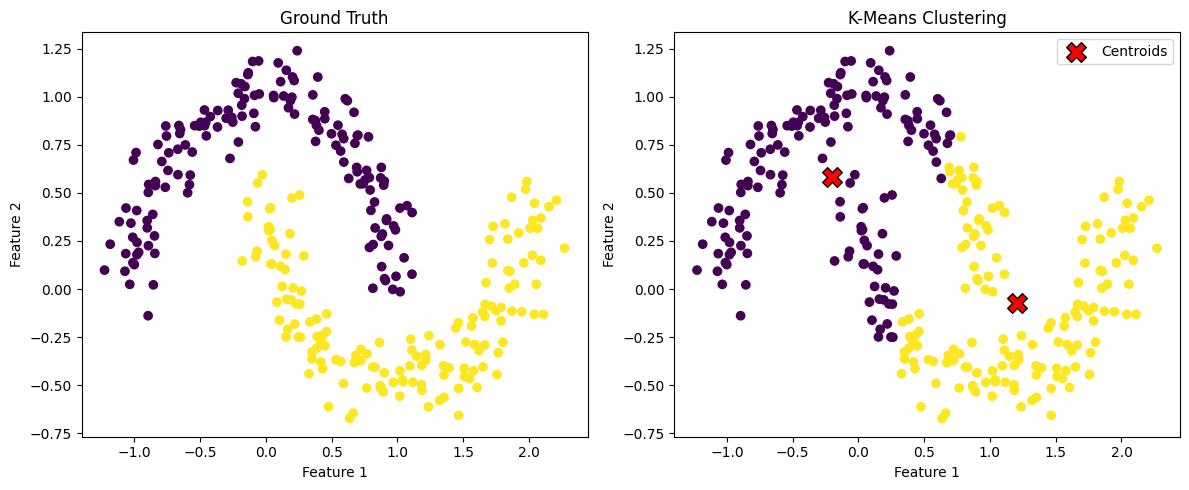

In [12]:
# TODO: Create a subplot comparing ground truth and K-Means predictions (5 points)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=y)
axes[0].set_title("Ground Truth")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X[:, 0], X[:, 1], c=labels)
axes[1].scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X',
                c='red', edgecolors='black', label='Centroids')
axes[1].set_title("K-Means Clustering")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()

plt.tight_layout()
plt.show()

"""
## **4. Implement RBF Kernel Function**
### Task 4: Write your own RBF kernel function
"""

In [14]:
def rbf_kernel(X, gamma=1.0):
    """
    TODO: Implement the RBF (Gaussian) kernel matrix
    Hint: Use pairwise squared Euclidean distances and apply the RBF formula (10 points)
    """
    sq_dists = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
    K = np.exp(-gamma * sq_dists)
    return K

"""
## **5. Implement Kernel K-Means Clustering**
### Task 5: Use kernel trick to cluster data in transformed space
"""

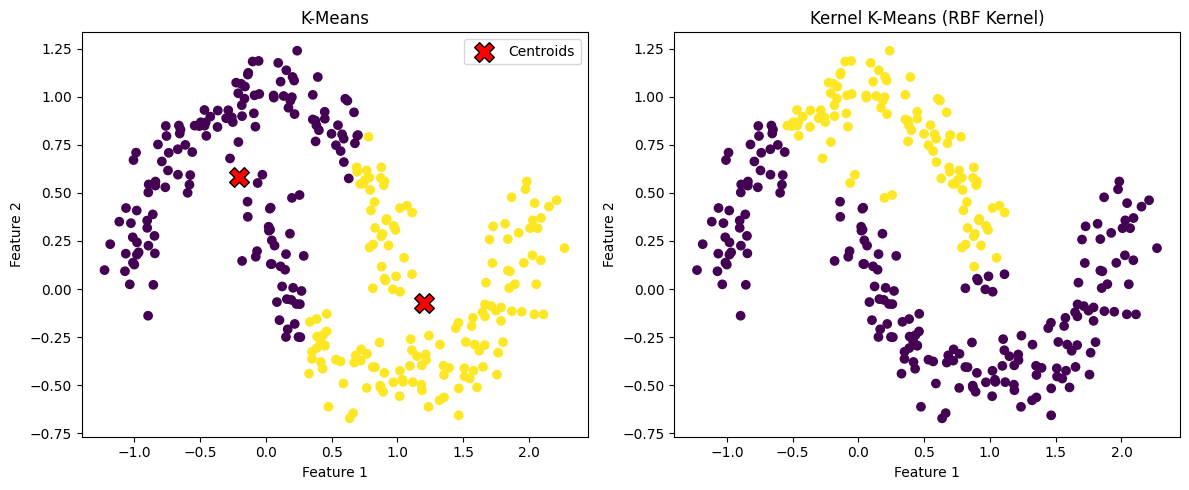

In [15]:
def kernel_kmeans(K, k, max_iters=100):
    """
    TODO: Implement Kernel K-Means clustering using precomputed kernel matrix K (10 points)
    - Randomly initialize cluster assignments
    - Update assignments using distances in kernel space
    Return final labels
    """
    n = K.shape[0]
    labels = np.random.randint(0, k, size=n)

    for _ in range(max_iters):
        old_labels = labels.copy()
        distances = np.zeros((n, k))

        for j in range(k):
            cluster_idx = np.where(labels == j)[0]

            if len(cluster_idx) == 0:
                distances[:, j] = np.inf
                continue

            cluster_size = len(cluster_idx)

            term1 = np.diag(K)
            term2 = (2 / cluster_size) * np.sum(K[:, cluster_idx], axis=1)
            term3 = (1 / cluster_size**2) * np.sum(K[np.ix_(cluster_idx, cluster_idx)])

            distances[:, j] = term1 - term2 + term3

        labels = np.argmin(distances, axis=1)
        if np.array_equal(labels, old_labels):
            break

    return labels

# TODO: Apply kernel_kmeans using RBF kernel matrix on the same dataset (5 points)
# TODO: Plot and compare clustering output with K-Means (5 points)
K = rbf_kernel(X, gamma=5.0)
np.random.seed(42)
kernel_labels = kernel_kmeans(K, k=2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=labels)
axes[0].scatter(centroids[:, 0], centroids[:, 1], s=200, marker='X',
                c='red', edgecolors='black', label='Centroids')
axes[0].set_title("K-Means")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], c=kernel_labels)
axes[1].set_title("Kernel K-Means (RBF Kernel)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

"""
### **Final Task: Answer the following questions in markdown cells. (1 point each)**
1. Why does K-Means fail to cluster the moon-shaped data correctly?
2. What is the intuition behind kernelizing a clustering algorithm?
3. How does the RBF kernel help separate non-linear data?
4. In what real-world scenarios would you prefer Kernel K-Means over standard K-Means?
5. What is the computational cost of Kernel K-Means compared to standard K-Means?

---
### **Submission Instructions:**
- Complete all the function implementations.
- Run and visualize clustering results.
- Answer the conceptual questions.
- Submit your completed notebook.
"""


1. K-Means fails to cluster the moon-shaped data correctly because it assumes that clusters are shaped like compact blobs around a center. It assigns points based on a straight-line distance to the centroids and updates each cluster accordingly. Since there are two moons, this results in the clustering appearing to be cut vertically down the middle instead of maintaining the original shape.

2. The intuition behind kernelizing a clustering algorithm is to avoid clustering in the original space when the two groups are not linearly separable. The purpose of using kernels is to allow you to measure similarity in data as if it had been mapped in a higher dimensional feature space. This makes clusters that look tangled in a 2D space much easier to separate.

3. The RBF kernel helps separate non-linear data because it gives high similarity to nearby points and very low similarity to far away points. This results in points on the same moon tending to remain strongly similar while points on different moons become less similar.

4. Kernel K-Means is preferable when working with smaller datasets with complex cluster shapes. Standard K-Means is pereferable when working with large datasets with simpler, more blob-like clusters.

5. Kernel K-Means computational cost is O(nkd) where n = the number of points, k = the number of clusters, and d = the number of features. Standard K-Means computational cost is O(n^2 * k) where n = the number of points and k = the number of clusters.